![Logo UOC](https://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/logotips/logo-UOC-2linies.png)

# TFG - Inteligencia Artificial
Enero de 2026

## Predicción de Respuesta a Tratamientos Oncológicos Basada en el Perfil Genético Mediante Técnicas de Aprendizaje Automático (ML) e Identificación de Genes Candidatos a Biomarcador Usando Técnicas de Explicabilidad (XAI) y Cuantificación de la Incertidumbre (UQ)

---

#### Pablo Vázquez Rodríguez
##### Grado en Ingeniería Informática
##### Inteligencia Artificial

#### Dra. María Moreno de Castro
#### Dr. Friman Sánchez

---

## Modelado (Paso 1): Selección de características supervisada

Como ya se comentó en el documento de exploración y preparación de datos durante el modelado se harán estas tareas:
1. Selección de características supervisada
2. Entrenamiento de modelos
3. Calibración del modelo
4. Análisis y selección del modelo optimizado

Durante la primera tarea se realiza una selección de genes basada en modelos de regresión logística, Random Forest, XGBoost y CatBoost, con filtrado no supervisado mediante Elbow/K-Means.

Durante la segunda tarea, se entrenan los modelos de nuevo esta vez sobre el conjunto que contiene sólo a los genes seleccionados. 

Durante la tercera tarea, tras el entrenamiento, se calibran los modelos.

Durante la cuarta tarea se hace un análisis de los modelos obtenidos, se valora su rendimiento, incertidumbre y se elige el modelo óptimo para los objetivos del proyecto.

## 0. Operaciones previas

### Carga de librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import optuna
from datetime import datetime
from scipy import stats
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, get_scorer, silhouette_score
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from kneed import KneeLocator
from aux.feature_selection import aggregation, clustering, ranking
from aux.ml_core import optimization, training

### Configuraciones iniciales

In [2]:
# Random generator de numpy con seed para reproducibilidad en el notebook
rng_seed = 19293
rng = np.random.default_rng(seed=rng_seed)

In [3]:
# Carga de los datasets
df_full = pd.read_csv("./data/full_top_significance_dataset.csv")
df_train = pd.read_csv("./data/train_dataset.csv")
df_test = pd.read_csv("./data/test_dataset.csv")
df_cal = pd.read_csv("./data/calibration_dataset.csv")

In [4]:
# VARIABLES ÚTILES

# Nombres de las columnas de genes
gene_columns = df_full.columns.difference(["Sample_id", "Response"])

### Funciones auxiliares

In [5]:
def check_df_consistency(df_original, df_final, n=100):
    """
    Comprueba aleatoriamente si los valores coinciden entre df_original y df_final
    para las mismas combinaciones de Sample_id y columna (gen).
    
    Parámetros
    ----------
    df_original : pandas dataframe
        DataFrame completo
    df_final : pandas dataframe
        DataFrame reducido (con Sample_id, Response y features seleccionadas)
    n : int
        número de comprobaciones aleatorias
    
    Imprime
    -------
    Los primeros 5 resultados de la comprobación
    
    Un mensaje final de éxito o fracaso
    """
    
    # Columnas que están en el dataset final (excluyendo Sample_id y Response)
    columnas_finales = [c for c in df_final.columns if c not in ["Sample_id", "Response"]]
    
    # Sample_ids presentes en df_final
    sample_ids = df_final["Sample_id"].unique()
    
    resultados = []
    
    for _ in range(n):
        # Elegir aleatoriamente un sample_id y una columna
        sample_id = rng.choice(sample_ids)
        col = rng.choice(columnas_finales)
        
        # Obtener valores
        orig_value = df_original.loc[df_original["Sample_id"] == sample_id, col].iloc[0]
        final_value = df_final.loc[df_final["Sample_id"] == sample_id, col].iloc[0]
        
        is_match = (orig_value == final_value)
        
        resultados.append(
            (str(sample_id), str(col), float(orig_value), float(final_value), bool(is_match)))
    
    # Mostrar solo los primeros 5
    print("Primeras 5 comprobaciones:")
    for r in resultados[:5]:
        print(r)
    
    # Mostrar mensaje final
    if all(r[-1] for r in resultados):
        print("\n##ÉXITO##: Verificación completada: todos los valores coinciden.\n-------\n")
    else:
        print("\nWARNING!! Inconsistencias detectadas: algunos valores no coinciden.")

### 1. Selección de características con filtrado no supervisado

Como para la regresión logística se necesita trabajar con los datos escalados y teniendo en cuenta que a los algoritmos de árboles no les afecta si está o no escalado el dataset, usaremos el dataset escalado para todos los modelos.

Además, como en este caso se quieren modelos sólo para valorar las características más importantes y estables entre ellos, vamos a explorar espacios relativamente grandes de hiperparámetros pero con relativamente pocas iteraciones de Optuna, ya que buscamos estabilidad de features y no tanto optimización de modelos.

In [6]:
# Escalado de los datasets

# Separar features y etiquetas
X_train = df_train[gene_columns]
y_train = df_train["Response"]

X_test = df_test[gene_columns]
y_test = df_test["Response"]

X_cal = df_cal[gene_columns]
y_cal = df_cal["Response"]

# Ajustar escalador con el dataset de train y aplicar a todos el mismo scaler
scaler = StandardScaler().set_output(transform='pandas')
scaler.fit(X_train)

# Guardar escalador
#
# NOTA: El scaler ha de guardarse porque en esa escala tendrán que estar todos 
# los datos que se quieran usar para que el modelo haga una predicción.
# Por ejemplo, si en el futuro un paciente se somete a un análisis de expresión
# génica y se nos pasan sus datos para que hagamos una predicción de respuesta
# al tratamiento, lo primero que habrá que hacer (siempre que nos den el dato
# ya procesado y transformado según RMA) será escalarlo con este escalador
# ya que los modelos se habrán entrenado con datos escalados a la escala que
# se define en scaler
# NOTA 2: El scaler sólo se puede aplicar a datos de entrada con las mismas 
# columnas (nombre y orden) que el dataset para el que se creó. Si se pasa
# un dato con más o menos columnas habrá de adaptarse según corresponda, eliminando
# y reordenando en el primer caso y añadiendo columnas con valor 0 y reordenando 
# en el segundo caso
joblib.dump(scaler, "./data/scaler.joblib")

# Transformar subconjuntos
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_cal_scaled = scaler.transform(X_cal)


# Reconstruir dataframes escalados
df_scaled_train = pd.concat([X_train_scaled, df_train[["Sample_id", "Response"]]], axis=1)
df_scaled_test = pd.concat([X_test_scaled, df_test[["Sample_id", "Response"]]], axis=1)
df_scaled_cal = pd.concat([X_cal_scaled, df_cal[["Sample_id", "Response"]]], axis=1)

In [7]:
df_scaled_train.head()

,ACADSB,ACSL5,ACTG2,AFF4,AIDA,ALPK1,ANAPC10,ANKH,APBB1IP,ARHGEF26,...,ZKSCAN1,ZNF12,ZNF254,ZNF322,ZNF362,ZNF37A,ZNF493,ZNF770,Sample_id,Response
0,0.068759,1.701427,0.450600,0.489768,0.977802,-0.228562,0.785137,1.088284,0.725568,0.092677,...,0.258043,1.415399,0.012254,0.744651,0.403143,0.187494,0.384819,0.495795,GSM710833,Non_response
1,-1.696018,-1.396258,-1.502706,-0.568810,-1.496928,0.086660,-2.253819,-0.629719,-0.452054,-1.073318,...,-0.117724,-1.393971,0.166354,-0.687051,-0.144325,0.146687,-0.626922,-0.432102,GSM1233118,Non_response
2,-0.431912,-0.959007,-0.950745,-1.352113,-0.922207,-0.683331,-0.626865,-1.331027,-1.010589,-1.023828,...,-0.650022,-0.980434,-0.980621,-0.890085,-1.181700,-1.124756,-1.136766,-1.290615,GSM505457,Non_response
3,0.604903,1.095648,0.392052,0.848281,1.338119,0.645354,0.743138,1.007238,1.392199,1.183191,...,0.759255,0.685386,0.756625,1.253303,1.661123,0.355810,0.836899,1.442518,GSM139539,Non_response
4,-0.779204,-0.718420,-0.873836,-1.359383,-0.939211,-0.966626,-0.949411,-1.176861,-1.243609,-0.956253,...,-1.020830,-0.838428,-1.327728,-0.873892,-1.273995,-1.230017,-1.172493,-1.222787,GSM590892,Non_response


In [8]:
# Datos de entrenamiento para selección de genes
X_train = df_scaled_train.drop(columns=["Response", "Sample_id"])
y_train_with_labels = df_scaled_train["Response"]

# Para simplificar el modelado con la función auxiliar, se decide en este punto
# transformar Response de Categórica a 0/1

# Clases objetivo a 0/1: Non_response=0, Response=1
le = LabelEncoder()
y_train = le.fit_transform(y_train_with_labels)

# Mostrar mapeo de clases
for i, label in enumerate(le.classes_): print(f"{i}: {label}")

0: Non_response
1: Response


In [9]:
# Crear los folds para la validación cruzada para garantizar que todos usan 
# el mismo fold de la misma forma y el objeto es exactamente el mismo para todos
training_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng_seed)
training_folds = list(training_cv.split(X_train, y_train))

**Regresión logística**:
* La clase es de tipo categórico, pero scikit learn la transforma automáticamente en LogisticRegression.
* Balanceada para paliar la asimetría del dataset
* Uso de elasticnet como método de regularización para mitigar correlaciones y por la complejidad del dataset
* Hiperparámetros:
    * **solver=saga**: Es el único que soporta elasticnet
    * **l1_ration**: Regularización Elasticnet: Balanceo de la regularización entre L1 y L2. Rango: \[0,1\]
    * **C**: Inverso de la regularización: Fuerza de la regularización aplicada. Valores pequeños (ej. 0.1) implican regularización fuerte, valores grandes (ej. 10, 100) implican regularización débil.

**NOTA**: La función auxiliar optimize_hyperparameters() incluye validación cruzada estratificada y acepta un grid para ajustar la búsqueda de los mejores hiperparámetros.

Se evalúan los espacios de hiperparámetros siguientes:
* **C**: 0.0001 a 10.0
* **l1_ratio**: 0.1 a 0.9

In [10]:
# NOTA: Esta celda tarda alrededor de 15 minutos en el hardware original usado
# Modelo de Regresión logística para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_feature_selection_logreg_model_study"

# Estimador
# NOTA: Logistic Regression no se puede paralelizar (aunque existe el parámetro n_jobs, no tiene efecto
#       ninguno y así lo pone su documentación, donde también indica que es un parámetro deprecated.
logreg = LogisticRegression(penalty="elasticnet", solver="saga", max_iter=5000, class_weight="balanced")

# Rangos de hiperparámetros
logreg_param_grid = {"C":        ["F", 0.0001, 10.0, {"log": True}], 
                      "l1_ratio": ["F", 0.1, 0.9, {}]}

# Mejores hiperparámetros encontrados
logreg_best_hiperparameters_data = optimization.optimize_hyperparameters(
    logreg, logreg_param_grid, X_train, y_train, n_trials=100, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 03:22:50,294] A new study created in RDB with name: 2025-12-23T03:22:49.916141_feature_selection_logreg_model_study
[I 2025-12-23 03:22:51,480] Trial 0 finished with value: 0.5431100082712985 and parameters: {'C': 0.0004081962130307901, 'l1_ratio': 0.18421781907399454}. Best is trial 0 with value: 0.5431100082712985.
[I 2025-12-23 03:22:59,491] Trial 1 finished with value: 0.6211170611743537 and parameters: {'C': 0.16917529565206987, 'l1_ratio': 0.6197716071065102}. Best is trial 1 with value: 0.6211170611743537.
[I 2025-12-23 03:23:21,203] Trial 2 finished with value: 0.6022387856025693 and parameters: {'C': 0.7788948903281334, 'l1_ratio': 0.887124371105384}. Best is trial 1 with value: 0.6211170611743537.
[I 2025-12-23 03:23:22,256] Trial 3 finished with value: 0.5431100082712985 and parameters: {'C': 0.000323008242945824, 'l1_ratio': 0.7815462193072592}. Best is trial 1 with value: 0.6211170611743537.
[I 2025-12-23 03:23:23,315] Trial 4 finished with value: 0.543110008

In [11]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {logreg_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", logreg_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", logreg_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T03:22:49.916141_feature_selection_logreg_model_study 

**Mejores parámetros**: {'C': 0.12955460909826474, 'l1_ratio': 0.16535114603112844} 

**F1**: 0.6263191980240386 

**Intervalo de scores F1**:  (0.5939849624060151, 0.6443514644351465)


**Valores que se han obtenido**

Checkpoint por si se vuelve a ejecutar y ya nos descuadra todo.
Si eso sucediese, debería bastar con recuperar el estudio de la base de datos de o bien entrenar el modelo con los parámetros obtenido y que se muestran aquí abajo: 

**Estudio (Optuna)**: 2025-12-23T03:22:49.916141_feature_selection_logreg_model_study 

**Mejores parámetros**: {'C': 0.12955460909826474, 'l1_ratio': 0.16535114603112844} 

**F1**: 0.6263191980240386 

**Intervalo de scores F1**:  (0.5939849624060151, 0.6443514644351465)

In [12]:
trained_logreg_model_data = training.train_with_best_params(
    logreg, logreg_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed, folds=training_folds)

In [13]:
logreg_votes_and_importances = aggregation.aggregate_importances_across_folds(
    trained_logreg_model_data['fold_importances'], top_k=50)

**Random Forest**

* Modelo basado en múltiples árboles de decisión entrenados sobre subconjuntos de datos y características.
* Robusto frente a overfitting gracias al bagging.
* Permite manejar datasets desbalanceados con class_weight="balanced".
* Para reproducibilidad random_state.
* Hiperparámetros clave:
    * **n_estimators**: Número de árboles. A más árboles más estabilidad pero más coste de procesado.
    * **max_depth**: Profundidad máxima de cada árbol. Controla el sobreajuste
    * **max_features**: Número de features consideradas en cada nodo. 
    * **min_samples_split**: Mínimo de muestras para dividir un nodo.
    * **min_samples_leaf**: Mínimo de muestras que se permiten que tenga un nodo.

Se evalúan todas las combinaciones de hiperparámetros siguientes:
* **n_estimators**: 100 a 600
* **max_depth**: 5 a 20
* **max_features**: "sqrt", "log2", 0.05, 0.1, 0.2
* **min_samples_split**: 2 a 20
* **min_samples_leaf**: 1 a 20

In [14]:
# NOTA: Esta celda tarda alrededor de 15 minutos en el hardware original usado
# Modelo Random Forest para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_feature_selection_rf_model_study"

# Estimador
rf = RandomForestClassifier(class_weight="balanced", random_state=rng_seed, n_jobs=-1)

# Rangos de hiperparámetros
rf_param_grid = {
    "n_estimators": ["I", 100, 600, {}],
    "max_depth": ["I", 5, 20, {}],
    "max_features": ["C", "sqrt", "log2", 0.05, 0.1, 0.2, {}],
    "min_samples_split": ["I", 2, 20, {}],
    "min_samples_leaf": ["I", 1, 20, {}],
}

# Mejores hiperparámetros encontrados
rf_best_hiperparameters_data = optimization.optimize_hyperparameters(
    rf, rf_param_grid, X_train, y_train, n_trials=100, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 03:29:23,512] A new study created in RDB with name: 2025-12-23T03:29:23.474591_feature_selection_rf_model_study
[I 2025-12-23 03:29:28,273] Trial 0 finished with value: 0.6254793837252342 and parameters: {'n_estimators': 309, 'max_depth': 7, 'max_features': 0.05, 'min_samples_split': 6, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.6254793837252342.
[I 2025-12-23 03:29:32,557] Trial 1 finished with value: 0.6260353649823125 and parameters: {'n_estimators': 254, 'max_depth': 13, 'max_features': 'sqrt', 'min_samples_split': 3, 'min_samples_leaf': 14}. Best is trial 1 with value: 0.6260353649823125.
[I 2025-12-23 03:29:36,956] Trial 2 finished with value: 0.6211876785677142 and parameters: {'n_estimators': 248, 'max_depth': 7, 'max_features': 0.2, 'min_samples_split': 19, 'min_samples_leaf': 19}. Best is trial 1 with value: 0.6260353649823125.
[I 2025-12-23 03:29:39,804] Trial 3 finished with value: 0.6274055254204953 and parameters: {'n_estimators': 143, 'max_depth

In [29]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {rf_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", rf_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", rf_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study 

**Mejores parámetros**: {'n_estimators': 558, 'max_depth': 13, 'max_features': 0.1, 'min_samples_split': 9, 'min_samples_leaf': 1} 

**F1**: 0.6379173741626156 

**Intervalo de scores F1**:  (0.6122448979591837, 0.6846846846846847)


**Valores que se han obtenido**

Checkpoint por si se vuelve a ejecutar y ya nos descuadra todo.
Si eso sucediese, debería bastar con recuperar el estudio de la base de datos de o bien entrenar el modelo con los parámetros obtenido y que se muestran aquí abajo: 

**Estudio (Optuna)**: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study 

**Mejores parámetros**: {'n_estimators': 558, 'max_depth': 13, 'max_features': 0.1, 'min_samples_split': 9, 'min_samples_leaf': 1} 

**F1**: 0.6379173741626156 

**Intervalo de scores F1**:  (0.6122448979591837, 0.6846846846846847)

In [17]:
trained_rf_model_data = training.train_with_best_params(
    rf, rf_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed, folds=training_folds)

In [18]:
rf_votes_and_importances = aggregation.aggregate_importances_across_folds(
    trained_rf_model_data['fold_importances'], top_k=50)

**XGBoost**

* Algoritmo de boosting basado en gradiente, muy eficiente y potente.
* Maneja correlaciones y complejidad del dataset mejor que Random Forest.
* Permite ponderar clases desbalanceadas con scale_pos_weight.
* No maneja variables categóricas automáticamente así que hay que codificarlas con 0/1
* Hiperparámetros clave:
    * *De árbol*
        * **n_estimators**: número de árboles.
        * **max_depth**: profundidad máxima.
        * **learning_rate**: tasa de aprendizaje.
        * **min_child_weight**: Peso mínimo de un nodo para permitir la división (reduce sobreajuste)
        * **gamma**: Umbral mínimo de mejora en la función de pérdida que debe aportar un split para ser aceptado
    * *De regularización*
        * **reg_alpha**: Regularización L1
        * **reg_lambda**: Regularización L2
    * *De muestreo*
        * **subsample**: fracción de muestras usadas en cada árbol.
        * **colsample_bytree**: fracción de features usadas en cada árbol.

XGBoost es mucho más pesado que los anteriores algoritmos, así que como sólo se necesita en este punto para selección de características se evaluará usando 5 iteraciones aleatorias del grid de parámetros.

Se evaluan 5 combinaciones aleatorias de los hiperparámetros siguientes:
* **n_estimators**: 200 a 1000
* **max_depth**: 2 a 6
* **learning_rate**: 0.01 a 0.3
* **min_child_weight**: 1 a 10
* **reg_alpha**: 0.001 a 10.0
* **reg_lambda**: 0.001 a 100.0
* **subsample**: 0.5 a 1.0
* **colsample_bytree**: 0.8 a 1.0
* **gamma**: 0.0 a 10.0


In [20]:
# NOTA: Esta celda tarda alrededor de 6 minutos en el hardware original usado
# Modelo XGBoost para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_feature_selection_xgboost_model_study"

# Ratio de balanceo
# 0: Non_response, 1: Response
balance_value = (y_train==0).sum() / (y_train==1).sum()

# Clases objetivo a binario: Non_response=0, Response=1
#le = LabelEncoder()
#y_train_encoded = le.fit_transform(y_train)

# Estimador
xgboost = XGBClassifier(scale_pos_weight=balance_value, eval_metric="auc", random_state=rng_seed, n_jobs=-1)

# Rangos de hiperparámetros
xgboost_param_grid = {
    "n_estimators": ["I", 200, 1000, {}],
    "max_depth": ["I", 2, 6, {}],
    "learning_rate": ["F", 0.01, 0.3, {"log": True}],
    "min_child_weight": ["I", 1, 10, {}],
    "reg_alpha": ["F", 0.001, 10.0, {"log": True}],
    "reg_lambda": ["F", 0.001, 100.0, {"log": True}],
    "subsample": ["F", 0.5, 1.0, {}],
    "colsample_bytree": ["F", 0.1, 0.8, {}],
    "gamma": ["F", 0.0, 10.0, {}]
}

# Mejores hiperparámetros encontrados
xgboost_best_hiperparameters_data = optimization.optimize_hyperparameters(
    xgboost, xgboost_param_grid, X_train, y_train, n_trials=100, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 03:37:28,730] A new study created in RDB with name: 2025-12-23T03:37:28.673017_feature_selection_xgboost_model_study
[I 2025-12-23 03:37:33,288] Trial 0 finished with value: 0.6071822804577854 and parameters: {'n_estimators': 794, 'max_depth': 2, 'learning_rate': 0.084710905893753, 'min_child_weight': 3, 'reg_alpha': 6.589602940072357, 'reg_lambda': 0.005483231299653007, 'subsample': 0.732875580720137, 'colsample_bytree': 0.20559104773478787, 'gamma': 3.57701549739307}. Best is trial 0 with value: 0.6071822804577854.
[I 2025-12-23 03:37:41,034] Trial 1 finished with value: 0.6317763108457324 and parameters: {'n_estimators': 427, 'max_depth': 5, 'learning_rate': 0.029271421330775586, 'min_child_weight': 5, 'reg_alpha': 0.03890125435604659, 'reg_lambda': 0.8782638270460469, 'subsample': 0.6196870591476327, 'colsample_bytree': 0.6176052153791973, 'gamma': 1.0962580792277477}. Best is trial 1 with value: 0.6317763108457324.
[I 2025-12-23 03:37:46,390] Trial 2 finished with va

In [30]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {xgboost_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", xgboost_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", xgboost_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study 

**Mejores parámetros**: {'n_estimators': 326, 'max_depth': 5, 'learning_rate': 0.15939904907225635, 'min_child_weight': 10, 'reg_alpha': 0.29581173901130614, 'reg_lambda': 1.38777274734027, 'subsample': 0.6013748768098586, 'colsample_bytree': 0.713955566997697, 'gamma': 1.3210534952090258} 

**F1**: 0.638627397377381 

**Intervalo de scores F1**:  (0.609375, 0.6889952153110048)


**Valores que se han obtenido**

Checkpoint por si se vuelve a ejecutar y ya nos descuadra todo.
Si eso sucediese, debería bastar con recuperar el estudio de la base de datos de o bien entrenar el modelo con los parámetros obtenido y que se muestran aquí abajo: 

**Estudio (Optuna)**: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study 

**Mejores parámetros**: {'n_estimators': 326, 'max_depth': 5, 'learning_rate': 0.15939904907225635, 'min_child_weight': 10, 'reg_alpha': 0.29581173901130614, 'reg_lambda': 1.38777274734027, 'subsample': 0.6013748768098586, 'colsample_bytree': 0.713955566997697, 'gamma': 1.3210534952090258} 

**F1**: 0.638627397377381 

**Intervalo de scores F1**:  (0.609375, 0.6889952153110048)

In [22]:
trained_xgboost_model_data = training.train_with_best_params(
    xgboost, xgboost_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed, folds=training_folds)

In [23]:
xgboost_votes_and_importances = aggregation.aggregate_importances_across_folds(
    trained_xgboost_model_data['fold_importances'], top_k=50)

**CatBoost**

* Algoritmo de boosting que maneja automáticamente variables categóricas.
* Muy eficiente en datasets con alta cardinalidad y correlaciones.
* Permite ponderar clases desbalanceadas con class_weights y pasándole una lista de pesos por clase.
* Hiperparámetros clave:
    * **iterations**: número de árboles.
    * **depth**: profundidad máxima.
    * **learning_rate**: tasa de aprendizaje.
    * **l2_leaf_reg**: regularización L2 en hojas.
    * **rsm**: Fracción de las características a usar en cada iteración de boosting.
    * **border_count**: Número de splits para características numéricas. Valores bajos=más simple, más rápido, más regularización. Valores altos más precisión, pero más riesgo de overfitting.

CatBoost, también es más pesado que los Regresión Logística y que Random Forest, así que como sólo se necesita en este punto para selección de características se evaluará usando 5 iteraciones aleatorias del grid de parámetros.

Se evaluan 5 combinaciones aleatorias de los hiperparámetros siguientes:
* **iterations**: 200 a 1000
* **depth**: 2 a 8
* **learning_rate**: 0.01 a 0.3
* **l2_leaf_reg**: 1.0 a 5.0
* **border_count**: 32 a 255
* **rsm**: 0.8 a 1.0

In [24]:
# NOTA: Esta celda tarda alrededor de 10 minutos en el hardware original usado
# Modelo CatBoost para selección de genes

# Fecha y hora de la ejecución (para que los nombres de estudio siempre sean únicos)
now = datetime.now().isoformat()
study_name = f"{now}_feature_selection_catboost_model_study"

# Ratio de balanceo
# 0: Non_response, 1: Response
balance_value = (y_train==0).sum() / (y_train==1).sum()

# Estimador
catboost = CatBoostClassifier(class_weights=[1, balance_value], eval_metric="AUC", 
                              early_stopping_rounds=50, random_state=rng_seed, thread_count=-1, task_type="CPU")

# Rangos de hiperparámetros
catboost_param_grid = {
    "iterations": ["I", 200, 1000, {}],
    "depth": ["I", 2, 8, {}],
    "learning_rate": ["F", 0.01, 0.3, {"log": True}],
    "l2_leaf_reg": ["F", 1.0, 50.0, {"log": True}],
    "border_count": ["I", 32, 255, {}],
    "rsm": ["F", 0.8, 1.0, {}]
}

# Mejores hiperparámetros encontrados
catboost_best_hiperparameters_data = optimization.optimize_hyperparameters(
    catboost, catboost_param_grid, X_train, y_train, n_trials=100, folds=training_folds, rng_seed=rng_seed, 
    study_name=study_name, store_study=True)

[I 2025-12-23 03:41:28,868] A new study created in RDB with name: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study
[I 2025-12-23 03:41:31,603] Trial 0 finished with value: 0.6112928528860653 and parameters: {'iterations': 498, 'depth': 2, 'learning_rate': 0.15133481742413304, 'l2_leaf_reg': 2.0325412761350905, 'border_count': 225, 'rsm': 0.82018988032824}. Best is trial 0 with value: 0.6112928528860653.
[I 2025-12-23 03:41:39,073] Trial 1 finished with value: 0.6252352515992885 and parameters: {'iterations': 407, 'depth': 7, 'learning_rate': 0.09797150093768639, 'l2_leaf_reg': 1.063415326879056, 'border_count': 61, 'rsm': 0.8464666595748885}. Best is trial 1 with value: 0.6252352515992885.
[I 2025-12-23 03:41:46,160] Trial 2 finished with value: 0.592800373255295 and parameters: {'iterations': 884, 'depth': 6, 'learning_rate': 0.012825244430514082, 'l2_leaf_reg': 2.0308799023172477, 'border_count': 187, 'rsm': 0.8452017129798723}. Best is trial 1 with value: 0.62523525

In [25]:
print(f"**Estudio (Optuna)**: {study_name}",
    f"\n\n**Mejores parámetros**: {catboost_best_hiperparameters_data["best_params"]}",
      f"\n\n**F1**:", catboost_best_hiperparameters_data["best_score"],
      f"\n\n**Intervalo de scores F1**: ", catboost_best_hiperparameters_data["best_score_interval"])

**Estudio (Optuna)**: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study 
**Mejores parámetros**: {'iterations': 885, 'depth': 8, 'learning_rate': 0.09960356001841793, 'l2_leaf_reg': 17.425888907920623, 'border_count': 60, 'rsm': 0.9480723104363594} 
**F1**: 0.6471843467672663 
**Intervalo de scores F1**:  (0.6153846153846154, 0.6918918918918919)


**Valores que se han obtenido**

**Estudio (Optuna)**: 2025-12-23T03:41:28.830626_feature_selection_catboost_model_study 

**Mejores parámetros**: {'iterations': 885, 'depth': 8, 'learning_rate': 0.09960356001841793, 'l2_leaf_reg': 17.425888907920623, 'border_count': 60, 'rsm': 0.9480723104363594} 

**F1**: 0.6471843467672663 

**Intervalo de scores F1**:  (0.6153846153846154, 0.6918918918918919)

In [27]:
trained_catboost_model_data = training.train_with_best_params(
    catboost, catboost_best_hiperparameters_data['best_params'], X_train, y_train, rng_seed=rng_seed, folds=training_folds)

0:	total: 8.67ms	remaining: 7.67s
1:	total: 16.4ms	remaining: 7.26s
2:	total: 25.1ms	remaining: 7.37s
3:	total: 35.4ms	remaining: 7.8s
4:	total: 43ms	remaining: 7.56s
5:	total: 52.1ms	remaining: 7.64s
6:	total: 59.6ms	remaining: 7.47s
7:	total: 72.4ms	remaining: 7.93s
8:	total: 79.8ms	remaining: 7.77s
9:	total: 87.4ms	remaining: 7.65s
10:	total: 96.8ms	remaining: 7.69s
11:	total: 105ms	remaining: 7.63s
12:	total: 112ms	remaining: 7.54s
13:	total: 121ms	remaining: 7.55s
14:	total: 129ms	remaining: 7.47s
15:	total: 136ms	remaining: 7.41s
16:	total: 145ms	remaining: 7.41s
17:	total: 152ms	remaining: 7.34s
18:	total: 161ms	remaining: 7.34s
19:	total: 169ms	remaining: 7.3s
20:	total: 178ms	remaining: 7.32s
21:	total: 185ms	remaining: 7.27s
22:	total: 194ms	remaining: 7.27s
23:	total: 201ms	remaining: 7.23s
24:	total: 213ms	remaining: 7.33s
25:	total: 222ms	remaining: 7.33s
26:	total: 229ms	remaining: 7.29s
27:	total: 242ms	remaining: 7.41s
28:	total: 253ms	remaining: 7.46s
29:	total: 264ms	

In [28]:
catboost_votes_and_importances = aggregation.aggregate_importances_across_folds(
    trained_catboost_model_data['fold_importances'], top_k=50)

Una vez tenemos los modelos entrenados tenemos que hacer los siguientes pasos:

1. Obtener las importancias de cada modelo
2. Normalizarlas (para poder compararlas)
3. Combinar los rankings de cada modelo
4. Seleccionar las mejores features según el ranking global

#### 1.1 Obtener importancias de cada modelo

Dado que cada modelo calcula la importancia de forma distinta (LogReg: Coeficientes, RandomForest: Gini, XGBoost: Gain, CatBoost: Loss change), las importancias no son directamente comparables en escala absoluta.

Para hacerlas comparables, se normalizan a \[0, 1\] dentro de cada modelo, lo que permite comparar posiciones relativas.

Sin embargo, la normalización no resuelve la inestabilidad entre folds ni la heterogeneidad entre modelos, por lo que se utiliza un enfoque basado en votos (frecuencia de aparición en el top‑K) para identificar las características que muestran un comportamiento consistente a lo largo de las distintas particiones, y en la importancia media normalizada.

<https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-in-logistic-regression-models>

<https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#randomforestclassifier>

<https://xgboosting.com/xgboost-gain-feature-importance/>

<https://catboost.ai/docs/en/concepts/fstr#regular-feature-importances__lossfunctionchange>

In [31]:
model_importance_dicts = [
    logreg_votes_and_importances,
    rf_votes_and_importances,
    xgboost_votes_and_importances,
    catboost_votes_and_importances,
]
final_importances_ranking_data = aggregation.aggregate_importances_across_models(model_importance_dicts)

In [32]:
raw_feature_importance_ranking = ranking.build_feature_ranking_dataframe(
    X_train.columns, 
    final_importances_ranking_data["total_votes"], 
    final_importances_ranking_data["total_importances"], 
    final_importances_ranking_data["final_ranking"])

En este punto se podría directamente coger el top X por importancia, pero se llevará a cabo una selección basada en elbow o kmeans para determinar el punto de corte que decidirá las características que finalmente se seleccionan. Se elegirá el que defina un grupo que arroje un número cercano a las 20 características deseadas.

Como el ranking se basa en una ordenación primero por número de votos (derivado de la validación cruzada de cada modelo) y desempate usando importancia media, se necesita combinar/codificar esa idea en un sólo score, para que sea más sencilla la aplicación de elbow y kmeans.

Para crear ese score y respetar la jerarquía de los votos sobre la importancia media, se hará una suma ponderada de la siguiente forma:
score = a · votos_normalizados + b · importancia_media_normalizada

Siendo a y b los coeficientes con los que se define esa importancia jerárquica que si se desea mantener debe cumplirse que a > b.
Los valores que se usarán son:
a=0.66
b=0.34

In [33]:
final_feature_ranking_with_score = \
    ranking.build_final_feature_dataframe(final_importances_ranking_data, feature_names=X_train.columns, a=0.7, b=0.3)
final_feature_ranking_with_score

,feature,total_votes,total_importances,score
0,RSU1,18.0,2.249652,0.971363
1,IKZF3,16.0,2.465283,0.922222
2,CHEK1,14.0,2.009132,0.783864
3,EHF,13.0,1.896716,0.730046
4,CCNK,13.0,1.642014,0.696220
...,...,...,...,...
318,GADD45GIP1,0.0,0.293565,0.011581
319,ZNF322,0.0,0.286539,0.010647
320,MPZL2,0.0,0.276727,0.009344
321,MLLT1,0.0,0.249892,0.005780


#### 1.4 Seleccionar las mejores features según importancia global

Llegados a este punto hay que decidir dónde cortar. Se comentó durante la fase de exploración que como referencia, para priorizar la explicabilidad operativa, el objetivo para el dataset final sería tener alrededor de unas 20 características. Esa es la referencia, el número concreto lo decidiremos en base a criterio técnico.

Se probarán los siguientes métodos para seleccionar las características finales:
* **Usar detección de codo**: Ordenar las importancias de mayor a menor y detectar el codo.
* **Clusterizar con k-means**: Crear clústers basados en 3 niveles de importancia (alta, media, baja) y seleccionar las características del clúster de mayor importancia media.

**Detección de codo**

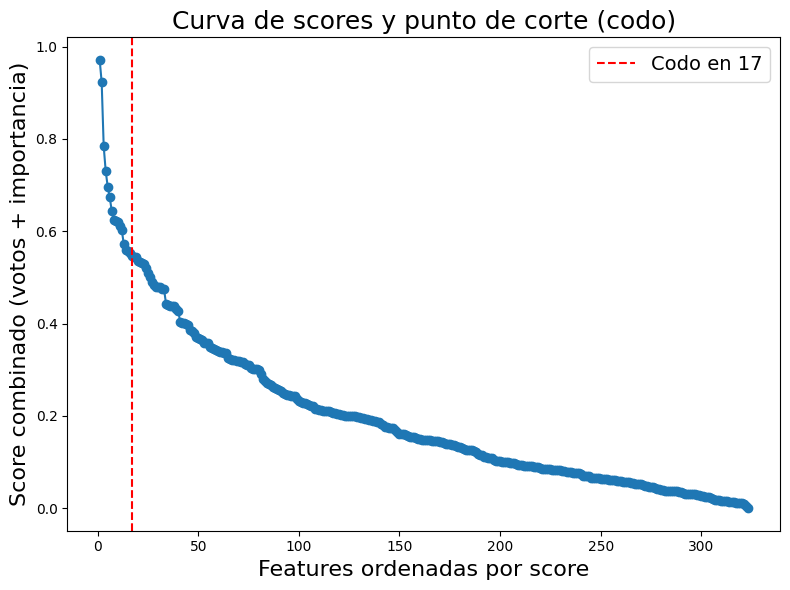

El punto de corte sugerido por KneeLocator es: 17 features

17 features seleccionadas: ['RSU1', 'IKZF3', 'CHEK1', 'EHF', 'CCNK', 'MANEA', 'MAD2L1', 'AZI2', 'PLXDC2', 'DCTN4', 'EML4', 'CCND2', 'EEA1', 'HS2ST1', 'SLC26A2', 'LYRM2', 'IFRD1']


In [51]:
elbow_point, elbow_selected_features = \
    clustering.run_elbow_on_scores(final_feature_ranking_with_score, save_path="./data/figures/elbow_features_importance.pdf")

**Elección de clúster con mayor importancia media K-means**

In [35]:
sil_scores = clustering.compute_silhouette_scores(final_feature_ranking_with_score, rng_seed=rng_seed)

Silhouette scores por número de clusters:
k=2: 0.6702
k=3: 0.6076
k=4: 0.5715
k=5: 0.5913
k=6: 0.5646


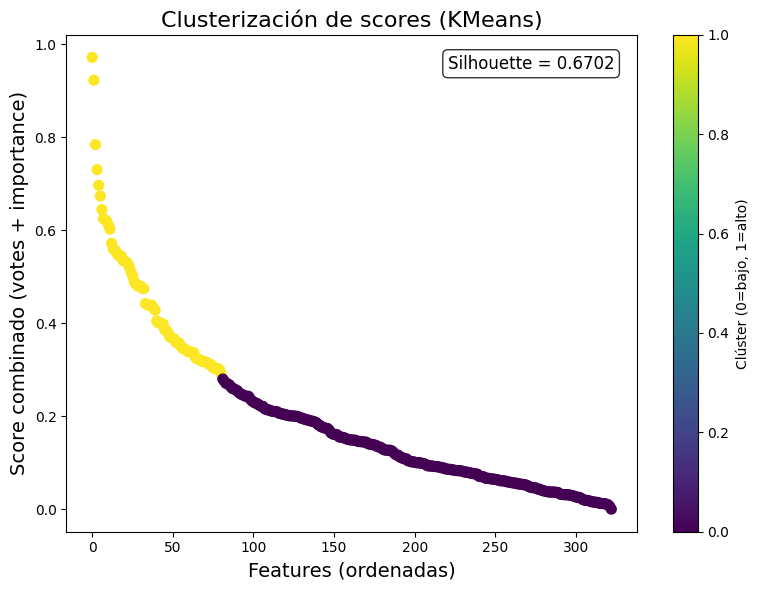

Silhouette score: 0.6702
81 features seleccionadas: ['RSU1', 'IKZF3', 'CHEK1', 'EHF', 'CCNK', 'MANEA', 'MAD2L1', 'AZI2', 'PLXDC2', 'DCTN4', 'EML4', 'CCND2', 'EEA1', 'HS2ST1', 'SLC26A2', 'LYRM2', 'IFRD1', 'TOP2A', 'ACADSB', 'PRKAA1', 'GTF2A1', 'THNSL1', 'ATP11A', 'KLHL7', 'ILF2', 'LMTK2', 'STMN3', 'SYTL2', 'LUM', 'AFF4', 'CDK6', 'MEX3C', 'ASPM', 'BACE2', 'HDAC2', 'NADSYN1', 'KLHL36', 'YIPF5', 'LACTB2', 'PMEPA1', 'CAMK1D', 'SNX16', 'CSGALNACT2', 'KPNA4', 'EGR1', 'SLC44A1', 'FNDC3B', 'MECOM', 'RAB28', 'RFX7', 'ACTG2', 'VANGL1', 'RCBTB1', 'CRIPT', 'CXCL2', 'FERMT1', 'UBE2S', 'CDCA3', 'CBL', 'PHC3', 'MAP3K8', 'HLA-DQA1', 'FAM135A', 'LGR4', 'HIC1', 'GATA6', 'MAP3K6', 'QSER1', 'CDT1', 'MEGF8', 'MGAT4A', 'MDM4', 'MIS18BP1', 'TNFRSF11A', 'CDKN2B', 'MGAT4B', 'SH2D3C', 'RNF19A', 'TRAF3IP1', 'PCCA', 'SERPINE2']


In [36]:
df_kmeans2, kmeans2_selected_features, _ = clustering.run_kmeans_on_scores(final_feature_ranking_with_score, n_clusters=2, rng_seed=rng_seed)

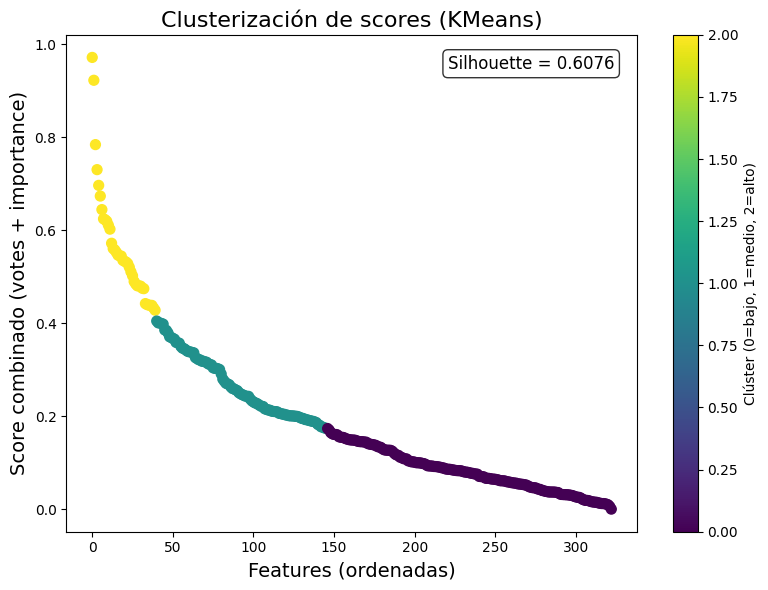

Silhouette score: 0.6076
40 features seleccionadas: ['RSU1', 'IKZF3', 'CHEK1', 'EHF', 'CCNK', 'MANEA', 'MAD2L1', 'AZI2', 'PLXDC2', 'DCTN4', 'EML4', 'CCND2', 'EEA1', 'HS2ST1', 'SLC26A2', 'LYRM2', 'IFRD1', 'TOP2A', 'ACADSB', 'PRKAA1', 'GTF2A1', 'THNSL1', 'ATP11A', 'KLHL7', 'ILF2', 'LMTK2', 'STMN3', 'SYTL2', 'LUM', 'AFF4', 'CDK6', 'MEX3C', 'ASPM', 'BACE2', 'HDAC2', 'NADSYN1', 'KLHL36', 'YIPF5', 'LACTB2', 'PMEPA1']


In [49]:
df_kmeans3, kmeans3_selected_features, _ = \
    clustering.run_kmeans_on_scores(final_feature_ranking_with_score, n_clusters=3, rng_seed=rng_seed, 
                                   save_path="./data/figures/kmeans3_features_importance.pdf")

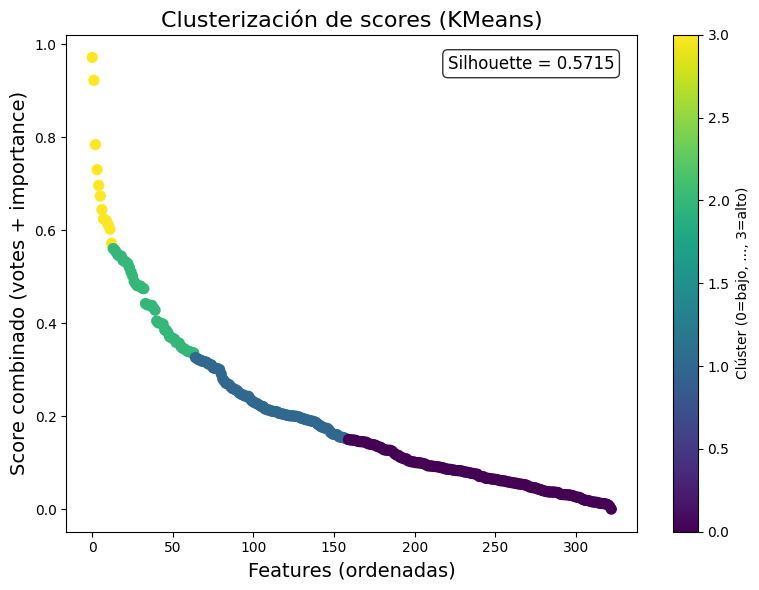

Silhouette score: 0.5715
13 features seleccionadas: ['RSU1', 'IKZF3', 'CHEK1', 'EHF', 'CCNK', 'MANEA', 'MAD2L1', 'AZI2', 'PLXDC2', 'DCTN4', 'EML4', 'CCND2', 'EEA1']


In [53]:
df_kmeans4, kmeans4_selected_features, _ = \
    clustering.run_kmeans_on_scores(final_feature_ranking_with_score, n_clusters=4, rng_seed=rng_seed,
                                   save_path="./data/figures/kmeans4_features_importance.pdf")

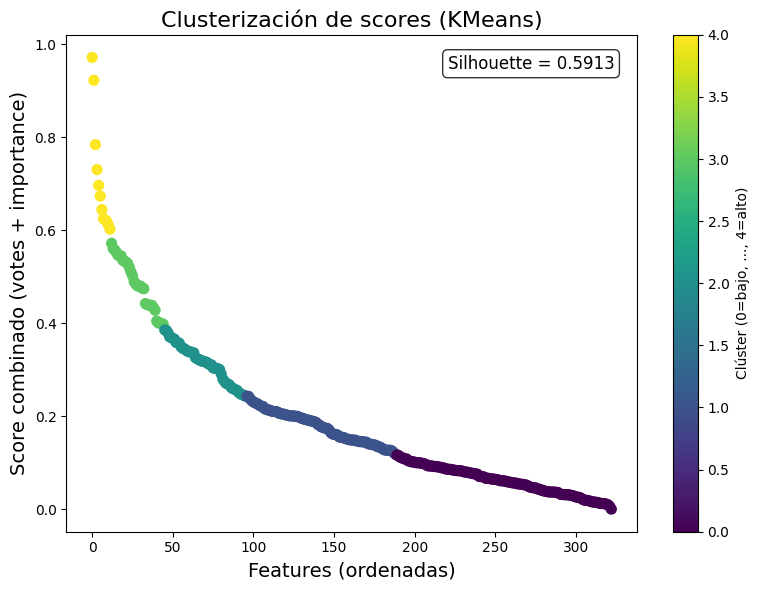

Silhouette score: 0.5913
12 features seleccionadas: ['RSU1', 'IKZF3', 'CHEK1', 'EHF', 'CCNK', 'MANEA', 'MAD2L1', 'AZI2', 'PLXDC2', 'DCTN4', 'EML4', 'CCND2']


In [40]:
df_kmeans5, kmeans5_selected_features, _ = clustering.run_kmeans_on_scores(final_feature_ranking_with_score, n_clusters=5, rng_seed=rng_seed)

In [41]:
# Selección de las features indicadas según el método que más
# se haya acercado al número de referencia de 20 características.
reference_value = 20

# Resultados de K-means
kmeans_results = {
    2: kmeans2_selected_features, 
    3: kmeans3_selected_features, 
    4: kmeans4_selected_features, 
    5: kmeans5_selected_features 
}

# 1. Calcular diferencia del elbow
best_method = "elbow"
best_features = elbow_selected_features
best_diff = abs(len(elbow_selected_features) - reference_value)

# 2. Comparar con todos los k-means disponibles
for k, feats in kmeans_results.items():
    diff = abs(len(feats) - reference_value)
    if diff < best_diff:
        best_method = f"kmeans_k={k}"
        best_features = feats
        best_diff = diff

# 3. Resultado final
print(f"Se seleccionan las features según el método: {best_method}")
print(f"{len(best_features)} features: {best_features}")

Se seleccionan las features según el método: elbow
17 features: ['RSU1', 'IKZF3', 'CHEK1', 'EHF', 'CCNK', 'MANEA', 'MAD2L1', 'AZI2', 'PLXDC2', 'DCTN4', 'EML4', 'CCND2', 'EEA1', 'HS2ST1', 'SLC26A2', 'LYRM2', 'IFRD1']


#### 1.5 Creación de los datasets finales con las características selecionadas

Por si en otro momento se quieren probar otros análisis, con los datasets con las características seleccionadas se crearán versiones finales del dataset completo original, todos los subconjuntos usados y todos los subconjuntos escalados.

**NOTA**: Esto también valdrá en caso de que por cualquier problema de aleatorización el presente notebook deje de tener datos coherentes con el estudio. Estos ficheros creados aquí deberán valer para continuar el estudio a partir de este punto como copia de seguridad.

In [42]:
# Definir las columnas finales
final_columns = best_features + ["Sample_id", "Response"]

# Crear versiones finales de cada dataset
df_full_final = df_full[final_columns].copy()

df_train_final = df_train[final_columns].copy()
df_test_final = df_test[final_columns].copy()
df_cal_final = df_cal[final_columns].copy()

df_scaled_train_final = df_scaled_train[final_columns].copy()
df_scaled_test_final = df_scaled_test[final_columns].copy()
df_scaled_cal_final = df_scaled_cal[final_columns].copy()

# Mostrar ejemplo de dataset final
print("Train final shape:", df_train_final.shape)
print("Calibration final shape:", df_cal_final.shape)
print("Test final shape:", df_test_final.shape)
df_train_final.head()

Train final shape: (1132, 19)
Calibration final shape: (473, 19)
Test final shape: (284, 19)


,RSU1,IKZF3,CHEK1,EHF,CCNK,MANEA,MAD2L1,AZI2,PLXDC2,DCTN4,EML4,CCND2,EEA1,HS2ST1,SLC26A2,LYRM2,IFRD1,Sample_id,Response
0,9.669390,5.986963,6.852984,9.993468,9.145763,7.294331,9.007194,8.031288,8.545334,10.014743,9.509815,10.683199,9.725240,9.007648,8.885438,7.682730,8.971135,GSM710833,Non_response
1,4.259175,4.137470,3.453796,9.026829,6.455882,1.795869,3.186549,5.905735,6.369733,5.806883,5.850047,7.451987,3.256540,2.091561,4.908377,6.563661,5.799656,GSM1233118,Non_response
2,6.811234,3.453388,4.649268,3.757320,4.442439,3.351304,6.069835,3.908131,4.081668,5.152343,5.338654,6.594495,3.948886,5.907531,4.284487,5.434322,5.752869,GSM505457,Non_response
3,11.355220,7.858737,9.962612,11.175200,9.727476,7.846528,10.643350,8.430252,9.103068,10.207260,10.359850,10.919680,9.452620,10.484160,9.027682,9.751994,7.141368,GSM139539,Non_response
4,6.051841,3.674148,4.612579,7.576103,4.685281,3.471402,5.744530,3.755324,4.511758,4.910448,5.566628,6.556687,3.634919,5.982529,4.585110,5.135099,4.784531,GSM590892,Non_response


Para rematar los datasets finales y guardarlos, primero conviene hacer alguna comprobación de integridad, estar seguros de que no se ha cometido algún error a la hora de manipular columnas, fusionar datos, etc.

La siguiente función comprueba si para el dataset original y el dataset final, la misma combinación de gen y sample_id siguen teniendo el mismo valor en ambos casos. Esa prueba se repite 'n' veces.

In [43]:
# Comprobación de 1000 datos aleatorios entre datasets iniciales y finales
check_df_consistency(df_full, df_full_final, n=1000)
check_df_consistency(df_train, df_train_final, n=1000)
check_df_consistency(df_test, df_test_final, n=1000)
check_df_consistency(df_cal, df_cal_final, n=1000)
check_df_consistency(df_scaled_train, df_scaled_train_final, n=1000)
check_df_consistency(df_scaled_test, df_scaled_test_final, n=1000)
check_df_consistency(df_scaled_cal, df_scaled_cal_final, n=1000)

Primeras 5 comprobaciones:
('GSM508160', 'CCND2', 10.65450713, 10.65450713, True)
('GSM1875944', 'MAD2L1', 9.46246222522571, 9.46246222522571, True)
('GSM1875953', 'CCNK', 9.91096389103496, 9.91096389103496, True)
('GSM508148', 'CCNK', 4.992426683, 4.992426683, True)
('GSM508126', 'IKZF3', 4.151848448, 4.151848448, True)

##ÉXITO##: Verificación completada: todos los valores coinciden.
-------

Primeras 5 comprobaciones:
('GSM590876', 'RSU1', 6.063669078, 6.063669078, True)
('GSM1619400', 'SLC26A2', 9.05543289005428, 9.05543289005428, True)
('GSM4171565', 'IKZF3', 6.27815827766792, 6.27815827766792, True)
('GSM505404', 'CHEK1', 4.010472133, 4.010472133, True)
('GSM158234', 'AZI2', 9.05139761732512, 9.05139761732512, True)

##ÉXITO##: Verificación completada: todos los valores coinciden.
-------

Primeras 5 comprobaciones:
('GSM2805015', 'HS2ST1', 11.05501008, 11.05501008, True)
('GSM505448', 'SLC26A2', 5.469747994, 5.469747994, True)
('GSM505506', 'PLXDC2', 3.945601514, 3.945601514, Tr

Llegados a este punto ya se pueden guardar los datasets finales

In [44]:
# Guardamos los datasets
df_full_final.to_csv("./data/final/full_top_significance_reduced_feat.csv", index=False)
df_train_final.to_csv("./data/final/train_reduced_feat.csv", index=False)
df_test_final.to_csv("./data/final/test_reduced_feat.csv", index=False)
df_cal_final.to_csv("./data/final/cal_reduced_feat.csv", index=False)
df_scaled_train_final.to_csv("./data/final/scaled_train_reduced_feat.csv", index=False)
df_scaled_test_final.to_csv("./data/final/scaled_test_reduced_feat.csv", index=False)
df_scaled_cal_final.to_csv("./data/final/scaled_cal_reduced_feat.csv", index=False)